# Deep Learning para Series de Tiempo — Pronóstico con LSTM

**Curso:** CC3084 · Ciencia de Datos · **Semestre 02, 2026** · UVG

Este cuaderno recorre, de principio a fin, cómo se pronostica una serie de
tiempo con una red neuronal recurrente (LSTM). Vamos a tocar **cada concepto de
la clase de Deep Learning**:

- Convertir una serie en un problema supervisado con **ventanas deslizantes**.
- Preparar los datos: **escalado** y **división temporal** (sin barajar).
- Entrenar una **LSTM** y compararla contra una **línea base** simple.
- Evaluar con **MAE / RMSE / MAPE** y visualizar predicciones vs valores reales.
- Discutir **overfitting**, la **curva de pérdida** y **early stopping**.

> Objetivo pedagógico: no es ganarle a ARIMA, sino **ver el flujo completo** de
> un modelo de deep learning para series de tiempo.

## 1. Imports y reproducibilidad

Fijamos las semillas de NumPy y TensorFlow para que el cuaderno sea
**reproducible**: cada corrida da el mismo resultado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Reproducibilidad: misma corrida -> mismos resultados
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow", tf.__version__)

TensorFlow 2.21.0


## 2. Cargar y explorar la serie

Usamos la serie clásica **Air Passengers**: total mensual de pasajeros de
aerolíneas internacionales (1949-1960, 144 meses). Es un caso ideal porque tiene
**tendencia** creciente y **estacionalidad** anual muy visibles.

Cargamos desde `data/raw/` y, si el archivo no está, desde una URL de respaldo.
El **orden importa**: cada valor depende de los anteriores, y nuestro objetivo es
**pronosticar el siguiente valor a partir de los pasados**.

In [2]:
from pathlib import Path

ruta_local = Path("..") / "data" / "raw" / "airline-passengers.csv"
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(ruta_local if ruta_local.exists() else url)
df["Month"] = pd.to_datetime(df["Month"])
df = df.set_index("Month")

serie = df["Passengers"].astype(float)
print(f"{len(serie)} observaciones, de {serie.index.min():%Y-%m} a {serie.index.max():%Y-%m}")
serie.head()

144 observaciones, de 1949-01 a 1960-12


Month
1949-01-01    112.0
1949-02-01    118.0
1949-03-01    132.0
1949-04-01    129.0
1949-05-01    121.0
Name: Passengers, dtype: float64

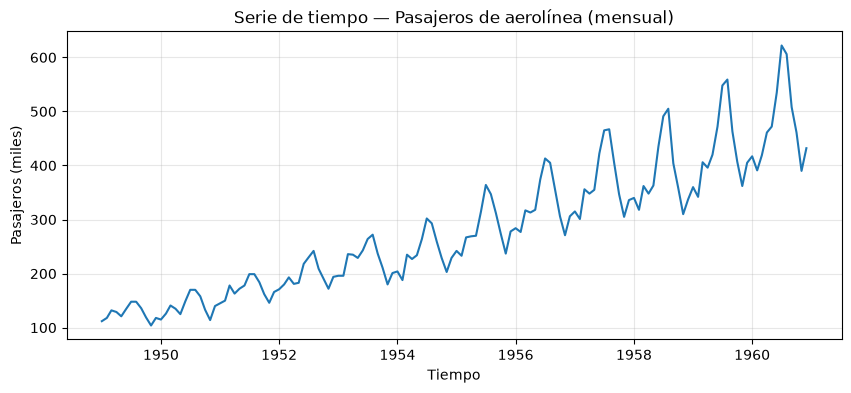

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(serie.index, serie.values)
plt.title("Serie de tiempo — Pasajeros de aerolínea (mensual)")
plt.xlabel("Tiempo"); plt.ylabel("Pasajeros (miles)")
plt.grid(alpha=0.3)
plt.show()

A simple vista se ven los dos patrones que la red tendrá que aprender:

- **Tendencia**: la serie crece de forma sostenida año tras año.
- **Estacionalidad**: cada año se repite el mismo ciclo (picos en verano, valles
  en invierno), con amplitud que crece con el nivel de la serie.

## 3. Escalado

Las redes neuronales son **sensibles a la escala** de los datos: valores en el
rango de cientos (como aquí) hacen que el entrenamiento sea inestable.
Normalizamos la serie al rango **[0, 1]** con `MinMaxScaler`.

> ⚠️ **Advertencia de fuga de información (leakage).** Aquí, por simplicidad del
> demo, ajustamos el scaler con **toda** la serie. En un escenario riguroso el
> scaler debe ajustarse **solo con el tramo de entrenamiento**, porque usar el
> mínimo/máximo del futuro filtra información que no tendríamos en producción. La
> versión rigurosa está en la sección 3.1.

In [4]:
scaler = MinMaxScaler()
serie_esc = scaler.fit_transform(serie.values.reshape(-1, 1)).flatten()

print(f"rango original: [{serie.min():.0f}, {serie.max():.0f}]")
print(f"rango escalado: [{serie_esc.min():.2f}, {serie_esc.max():.2f}]")

rango original: [104, 622]
rango escalado: [0.00, 1.00]


## 4. Ventanas deslizantes

Este es el **concepto central** de la clase: convertir la serie en pares
`(X, y)` para plantearla como un problema **supervisado**. Cada muestra `X` es
una ventana de `k` valores pasados, y `y` es el valor que sigue.

Ejemplo con `k = 3` (valores ilustrativos):

```
[10, 12, 13]  ->  15
[12, 13, 15]  ->  16
[13, 15, 16]  ->  18
```

La ventana se **desliza** un paso a la vez. Usamos `k = 12` (un ciclo estacional
completo) para que la red tenga contexto de todo un año.

In [5]:
def crear_ventanas(serie, k):
    X, y = [], []
    for i in range(len(serie) - k):
        X.append(serie[i:i + k])   # ventana de k valores pasados
        y.append(serie[i + k])     # el valor siguiente
    return np.array(X), np.array(y)

k = 12                                   # tamaño de la ventana (un ciclo estacional)
X, y = crear_ventanas(serie_esc, k)
X = X.reshape((X.shape[0], k, 1))        # (muestras, pasos, variables) para la LSTM

print(f"X: {X.shape}  (muestras, pasos, variables)")
print(f"y: {y.shape}")

X: (132, 12, 1)  (muestras, pasos, variables)
y: (132,)


## 5. División temporal

**Nunca** usamos datos del futuro para entrenar. Por eso el conjunto de prueba es
el **tramo final** de la serie (últimos 20 %), **no** una muestra aleatoria.
Barajar aquí sería hacer trampa: el modelo vería el futuro.

In [6]:
corte = int(len(X) * 0.8)
X_train, X_test = X[:corte], X[corte:]
y_train, y_test = y[:corte], y[corte:]

print(f"entrenamiento: {len(X_train)} muestras")
print(f"prueba:        {len(X_test)} muestras")

entrenamiento: 105 muestras
prueba:        27 muestras


### 5.1 Versión rigurosa del escalado (sin fuga de información)

Para dejarlo claro: así se haría **sin leakage**. Se separa primero el tramo de
entrenamiento en la **serie original**, se ajusta el scaler **solo con ese
tramo** y luego se transforman ambos tramos. El resto del cuaderno sigue con la
versión simple (sección 3) por comodidad, pero esta es la forma correcta en
producción.

In [7]:
# indice temporal que separa train/test sobre la serie ORIGINAL
n_train = corte + k  # + k porque las primeras k observaciones se consumen al ventanear

scaler_riguroso = MinMaxScaler()
scaler_riguroso.fit(serie.values[:n_train].reshape(-1, 1))   # <-- solo train

serie_esc_rig = scaler_riguroso.transform(serie.values.reshape(-1, 1)).flatten()
print(f"scaler ajustado solo con las primeras {n_train} observaciones (train)")
print(f"nota: el tramo de prueba puede salirse de [0,1] -> "
      f"max = {serie_esc_rig[n_train:].max():.2f} (esperado por la tendencia creciente)")

scaler ajustado solo con las primeras 117 observaciones (train)
nota: el tramo de prueba puede salirse de [0,1] -> max = 1.29 (esperado por la tendencia creciente)


## 6. Línea base (naive)

Antes de traer deep learning, necesitamos una **línea base** que nos diga si la
red realmente aporta. La más simple: **predecir que el siguiente valor es igual
al último conocido**. Es sorprendentemente difícil de superar en series con
mucha inercia.

In [8]:
# prediccion ingenua = ultimo valor de cada ventana
y_pred_naive = X_test[:, -1, 0]
print(f"{len(y_pred_naive)} predicciones naive (aún en escala [0,1])")

27 predicciones naive (aún en escala [0,1])


## 7. Modelo LSTM

Construimos, compilamos y entrenamos una LSTM. Puntos clave:

- Una capa `LSTM` de 50 unidades procesa la secuencia; una `Dense(1)` produce el
  valor pronosticado.
- Usamos un **conjunto de validación** (`validation_split=0.2`) para vigilar el
  overfitting.
- **Early stopping** detiene el entrenamiento cuando la pérdida de validación
  deja de mejorar y **restaura los mejores pesos**: así elegimos las épocas
  mirando los datos, no un número fijo.

In [9]:
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(k, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

/Users/menene/code/data/03_deep_learning/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

hist = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[es],
    verbose=0,
)

print(f"entrenamiento detenido en la época {len(hist.history['loss'])} de 200 "
      f"(early stopping restauró los mejores pesos)")

entrenamiento detenido en la época 200 de 200 (early stopping restauró los mejores pesos)


## 8. Curva de pérdida

Graficamos la pérdida de **entrenamiento** vs **validación** por época. Aquí se
**ve** el overfitting: si la curva de validación empieza a subir mientras la de
entrenamiento sigue bajando, el modelo está memorizando. Early stopping corta
justo en el punto donde la validación deja de mejorar (línea punteada).

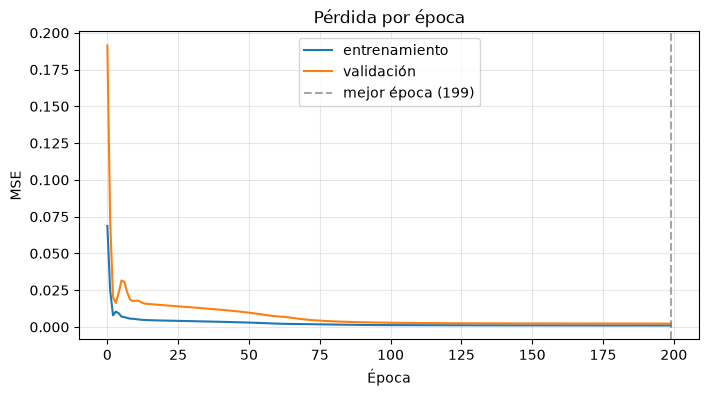

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(hist.history['loss'], label='entrenamiento')
plt.plot(hist.history['val_loss'], label='validación')
mejor_epoca = int(np.argmin(hist.history['val_loss']))
plt.axvline(mejor_epoca, color='gray', linestyle='--', alpha=0.7,
            label=f'mejor época ({mejor_epoca})')
plt.title("Pérdida por época")
plt.xlabel("Época"); plt.ylabel("MSE")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 9. Predicción y des-escalado

Predecimos sobre el conjunto de prueba y **volvemos a la escala original** para
poder interpretar y graficar los valores en pasajeros reales.

In [12]:
y_pred = model.predict(X_test, verbose=0).flatten()

def desescalar(v):
    return scaler.inverse_transform(np.array(v).reshape(-1, 1)).flatten()

y_test_real = desescalar(y_test)
y_pred_real = desescalar(y_pred)
y_naive_real = desescalar(y_pred_naive)

print("primeras 3 predicciones (escala original):")
for real, lstm, naive in zip(y_test_real[:3], y_pred_real[:3], y_naive_real[:3]):
    print(f"  real={real:6.1f}   LSTM={lstm:6.1f}   naive={naive:6.1f}")

primeras 3 predicciones (escala original):
  real= 359.0   LSTM= 398.4   naive= 404.0
  real= 310.0   LSTM= 361.6   naive= 359.0
  real= 337.0   LSTM= 341.9   naive= 310.0


## 10. Métricas

Comparamos la LSTM contra la línea base con tres métricas de error:

- **MAE** (error absoluto medio): promedio de la magnitud del error.
- **RMSE** (raíz del error cuadrático medio): penaliza más los errores grandes.
- **MAPE** (error porcentual absoluto medio): error relativo, en %.

In [13]:
def mae(a, b):  return np.mean(np.abs(a - b))
def rmse(a, b): return np.sqrt(np.mean((a - b) ** 2))
def mape(a, b): return np.mean(np.abs((a - b) / a)) * 100

print(f"{'modelo':6}  {'MAE':>7}  {'RMSE':>7}  {'MAPE':>7}")
print("-" * 34)
for nombre, pred in [("Naive", y_naive_real), ("LSTM", y_pred_real)]:
    print(f"{nombre:6}  {mae(y_test_real, pred):7.2f}  "
          f"{rmse(y_test_real, pred):7.2f}  {mape(y_test_real, pred):6.2f}%")

modelo      MAE     RMSE     MAPE
----------------------------------
Naive     43.78    50.74   10.00%
LSTM      35.05    44.71    7.62%


**Punto de discusión.** ¿La LSTM le gana a la línea base? Si no lo hace por mucho,
puede ser que la serie sea demasiado simple o corta para justificar deep
learning. Esa es exactamente la conversación de **"¿cuándo vale la pena deep
learning?"**: si un método trivial casi iguala a la red, el costo de entrenar y
mantener la red probablemente no se justifica.

## 11. Visualización: predicción vs real

Nada como ver las curvas encimadas. Comparamos los valores reales del conjunto de
prueba contra la LSTM y contra la línea base.

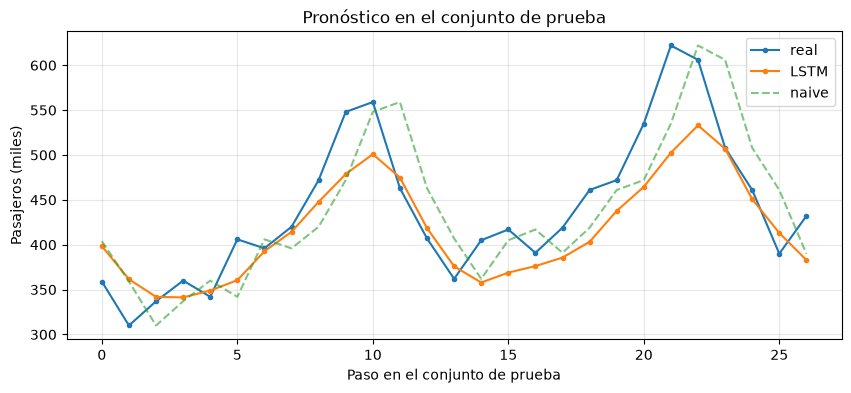

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(y_test_real, label='real', marker='.')
plt.plot(y_pred_real, label='LSTM', marker='.')
plt.plot(y_naive_real, label='naive', linestyle='--', alpha=0.6)
plt.title("Pronóstico en el conjunto de prueba")
plt.xlabel("Paso en el conjunto de prueba"); plt.ylabel("Pasajeros (miles)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 12. Pronóstico multi-paso (iterativo)

Hasta ahora predijimos **un paso** hacia adelante. Para pronosticar varios pasos,
alimentamos cada predicción de vuelta como entrada. El problema: los errores se
**acumulan**, porque el modelo empieza a predecir sobre sus propias predicciones
(no sobre datos reales). Esto ilustra la idea de **horizonte** de la clase.

In [15]:
def pronostico_iterativo(model, ventana_inicial, pasos):
    ventana = list(ventana_inicial)
    preds = []
    for _ in range(pasos):
        x = np.array(ventana[-k:]).reshape((1, k, 1))
        p = model.predict(x, verbose=0).flatten()[0]
        preds.append(p)
        ventana.append(p)          # la predicción se vuelve entrada del siguiente paso
    return desescalar(preds)

futuro = pronostico_iterativo(model, X_test[0, :, 0], pasos=24)
print(f"pronóstico iterativo a {len(futuro)} pasos generado")

pronóstico iterativo a 24 pasos generado


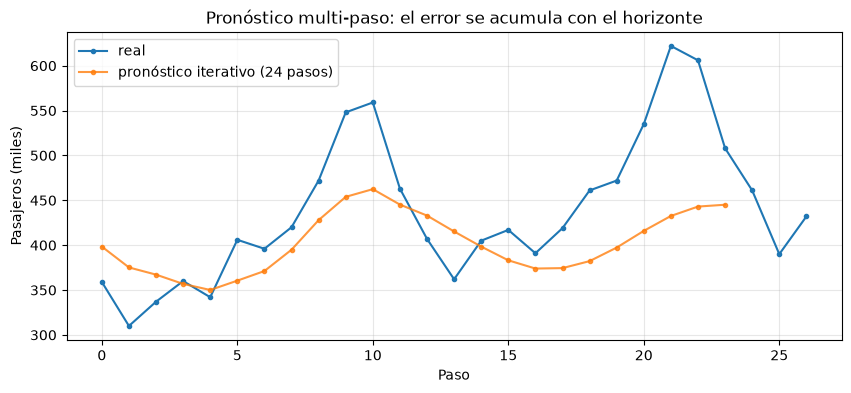

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(y_test_real, label='real', marker='.')
plt.plot(futuro, label='pronóstico iterativo (24 pasos)', marker='.', alpha=0.8)
plt.title("Pronóstico multi-paso: el error se acumula con el horizonte")
plt.xlabel("Paso"); plt.ylabel("Pasajeros (miles)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 13. Cierre y discusión

- **Escalado + división temporal** fueron clave: sin ellos el modelo falla o
  "hace trampa" viendo el futuro.
- **Early stopping** eligió las épocas mirando la validación, no un número fijo.
- Comparar contra una **línea base** evita vendernos humo: el deep learning solo
  vale la pena si supera lo simple.
- Los métodos **clásicos** (ARIMA, suavizado exponencial) siguen siendo fuertes
  en series cortas y univariadas como esta. Deep learning brilla cuando hay
  **muchos datos** y **relaciones complejas o multivariadas**.

## Retos para el estudiante

1. Cambia el tamaño de ventana `k` (6, 12, 24) y observa el efecto en las
   métricas.
2. Sustituye la LSTM por una **GRU** y por un **MLP** (aplanando la ventana).
   ¿Cuál gana?
3. Agrega una **segunda variable** (p. ej. un indicador de mes o feriado) y
   conviértelo en un problema **multivariado**.
4. **Quita el escalado** y vuelve a entrenar: observa cómo se degrada el
   aprendizaje.
5. Aumenta las épocas y **quita el early stopping**: identifica el punto donde
   empieza el overfitting.